# Post-cleaning descriptive statistics

Key facts for the **data section**, from the Stage 2 corpus (`reviews_corpus.parquet`) and the Stage 1 business→tract table.

- **Scope:** review years `config.CORPUS_DATE_WINDOW` (2013–2022), US study-state businesses only (the Stage 1 whitelist *is* the US-only filter).
- All **post-cleaning** — blank text, non-US and out-of-scope years already removed (Stage 2 funnel).

Run top-to-bottom; numbers refresh if the corpus is rebuilt.

In [1]:
%matplotlib inline
import sys, pathlib
# Make the project root (the folder with config.py) importable, so this
# notebook runs whether opened from notebooks/ or the repo root.
ROOT = pathlib.Path.cwd()
while not (ROOT / 'config.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

import config

CORPUS = config.PROCESSED_DIR / 'reviews_corpus.parquet'
BUSINESSES = config.INTERIM_DIR / f'businesses_with_tract_{config.ACS_YEARS[0]}.parquet'
print('corpus     :', CORPUS.name, '->', 'exists' if CORPUS.exists() else 'MISSING')
print('businesses :', BUSINESSES.name, '->', 'exists' if BUSINESSES.exists() else 'MISSING')
print('review-year scope (CORPUS_DATE_WINDOW):', config.CORPUS_DATE_WINDOW)

corpus     : reviews_corpus.parquet -> exists
businesses : businesses_with_tract_2018.parquet -> exists
review-year scope (CORPUS_DATE_WINDOW): (2013, 2022)


## Load
The heavy `text` column is skipped — not needed for the counts.

In [2]:
# Reviews: ids + stars + date only.
rev = pd.read_parquet(CORPUS, columns=['business_id', 'user_id', 'stars', 'date'])
rev['year'] = rev['date'].dt.year

# Businesses (Stage 1 matched set). Geography comes from the tract GEOID
# (first two digits = state FIPS), not the sometimes-wrong Yelp `state` label.
biz = pd.read_parquet(BUSINESSES, columns=['business_id', 'tract_geoid', 'stars', 'review_count'])
biz['state_fips'] = biz['tract_geoid'].str[:2]
biz['metro'] = biz['state_fips'].map(config.STATE_LABELS)

print(f'reviews (corpus rows)      : {len(rev):,}')
print(f'businesses (Stage 1 match) : {len(biz):,}')

reviews (corpus rows)      : 6,096,216
businesses (Stage 1 match) : 144,719


## 1. Headline facts

In [3]:
facts = {
    'review_year_scope': f'{config.CORPUS_DATE_WINDOW[0]}-{config.CORPUS_DATE_WINDOW[1]}',
    'reviews_total': len(rev),
    'businesses_in_corpus': rev['business_id'].nunique(),
    'businesses_matched_stage1': len(biz),
    'distinct_reviewers': rev['user_id'].nunique(),
    'study_metros': int(biz['metro'].nunique()),
    'date_min': rev['date'].min(),
    'date_max': rev['date'].max(),
    'mean_stars': round(float(rev['stars'].mean()), 3),
    'median_stars': float(rev['stars'].median()),
}
for k, v in facts.items():
    print(f'  {k:26s}: {v:,}' if isinstance(v, int) else f'  {k:26s}: {v}')

  review_year_scope         : 2013-2022
  reviews_total             : 6,096,216
  businesses_in_corpus      : 142,196
  businesses_matched_stage1 : 144,719
  distinct_reviewers        : 1,855,208
  study_metros              : 13
  date_min                  : 2013-01-01 00:00:17
  date_max                  : 2022-01-19 19:48:45
  mean_stars                : 3.756
  median_stars              : 4.0


## 2. Reviews per year

,reviews,share
year,,
2013,376361,0.062
2014,510952,0.084
2015,674291,0.111
2016,744948,0.122
2017,806242,0.132
2018,892741,0.146
2019,896557,0.147
2020,548907,0.090
2021,613850,0.101


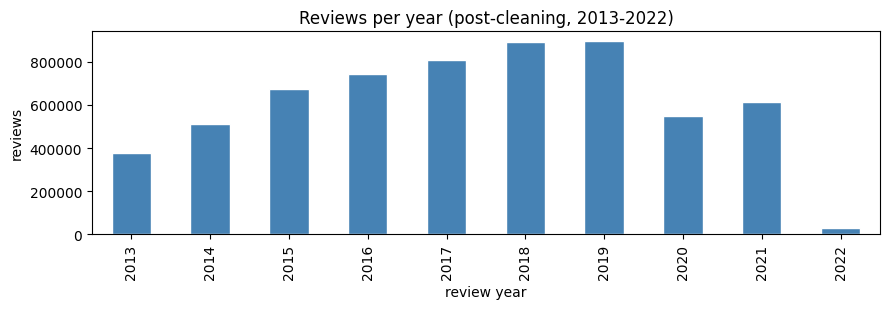

In [4]:
per_year = rev['year'].value_counts().sort_index()
per_year_tbl = per_year.rename_axis('year').to_frame('reviews')
per_year_tbl['share'] = (per_year_tbl['reviews'] / per_year_tbl['reviews'].sum()).round(3)
display(per_year_tbl)

ax = per_year.plot(kind='bar', figsize=(9, 3.2), color='steelblue', edgecolor='white')
ax.set_title('Reviews per year (post-cleaning, 2013-2022)')
ax.set_xlabel('review year'); ax.set_ylabel('reviews')
plt.tight_layout(); plt.show()

## 3. Star-rating distribution

In [5]:
stars = rev['stars'].value_counts().sort_index()
star_tbl = stars.rename_axis('stars').to_frame('reviews')
star_tbl['share'] = (star_tbl['reviews'] / star_tbl['reviews'].sum()).round(3)
display(star_tbl)

,reviews,share
stars,,
1.0,983136,0.161
2.0,460889,0.076
3.0,553897,0.091
4.0,1158719,0.190
5.0,2939575,0.482


## 4. Reviews per business

In [6]:
rpb = rev.groupby('business_id').size()
display(rpb.describe(percentiles=[.25, .5, .75, .9, .99]).round(1).to_frame('reviews_per_business'))

,reviews_per_business
count,142196.0
mean,42.9
std,113.2
min,1.0
25%,7.0
50%,14.0
75%,36.0
90%,95.0
99%,444.0
max,7167.0


## 5. Review length (words)
Exact, computed in batches over the full corpus (the `text` column is large).

In [7]:
parts = []
for batch in pq.ParquetFile(CORPUS).iter_batches(batch_size=250_000, columns=['text']):
    s = batch.column('text').to_pandas()
    parts.append(s.str.split().str.len().to_numpy())
words = pd.Series(np.concatenate(parts), name='words')
print(f'review length in words (all {len(words):,} reviews):')
display(words.describe(percentiles=[.25, .5, .75, .9, .99]).round(1).to_frame('words'))

review length in words (all 6,096,216 reviews):


,words
count,6096216.0
mean,101.0
std,95.2
min,1.0
25%,40.0
50%,72.0
75%,128.0
90%,209.0
99%,478.0
max,1070.0


## 6. Geography — reviews and businesses per study metro

In [8]:
rev_metro = rev.merge(biz[['business_id', 'metro']], on='business_id', how='left')
unmatched = int(rev_metro['metro'].isna().sum())
geo = (rev_metro.groupby('metro').size().rename('reviews').to_frame()
       .join(biz.groupby('metro').size().rename('businesses'))
       .sort_values('reviews', ascending=False))
geo.loc['TOTAL'] = geo.sum()
display(geo)
print(f'reviews with no matched business (should be 0): {unmatched:,}')
del rev_metro

,reviews,businesses
metro,,
Pennsylvania (Philadelphia),1325622,34046
Florida (Tampa),1100971,26303
Louisiana (New Orleans),669677,9925
Tennessee (Nashville),557413,12058
Indiana (Indianapolis),449920,11248
Missouri (St Louis),427093,10917
Nevada (Reno),389920,7717
Arizona (Tucson),383740,9916
California (Santa Barbara),297779,5175


reviews with no matched business (should be 0): 0


## 7. Tract coverage and the analysable sample
Tracts available for the evaluation ladder, for the configured ACS block (`REVIEW_WINDOWS`). Tracts below `MIN_REVIEWS_PER_TRACT` are flagged at Stage 5 and excluded from the primary Stage 6 ladder.

In [9]:
acs_year = config.ACS_YEARS[0]
w0, w1 = config.REVIEW_WINDOWS[acs_year]

rev_tract = rev.merge(biz[['business_id', 'tract_geoid']], on='business_id', how='left')
in_block = rev_tract[rev_tract['year'].between(w0, w1)]
per_tract = in_block.groupby('tract_geoid').size()
meets = int((per_tract >= config.MIN_REVIEWS_PER_TRACT).sum())

print(f'ACS block (REVIEW_WINDOWS[{acs_year}])             : reviews {w0}-{w1}')
print(f'tracts with >=1 business (Stage 1)         : {biz["tract_geoid"].nunique():,}')
print(f'tracts with >=1 review in {w0}-{w1}          : {per_tract.shape[0]:,}')
print(f'reviews in block {w0}-{w1}                   : {len(in_block):,}')
print(f'tracts meeting MIN_REVIEWS_PER_TRACT (>={config.MIN_REVIEWS_PER_TRACT})  : {meets:,}  <- analysable set')
display(per_tract.describe(percentiles=[.25, .5, .75, .9]).round(1).to_frame(f'reviews_per_tract_{w0}_{w1}'))
del rev_tract

ACS block (REVIEW_WINDOWS[2018])             : reviews 2014-2018
tracts with >=1 business (Stage 1)         : 3,820
tracts with >=1 review in 2014-2018          : 3,810
reviews in block 2014-2018                   : 3,629,174
tracts meeting MIN_REVIEWS_PER_TRACT (>=20)  : 3,444  <- analysable set


,reviews_per_tract_2014_2018
count,3810.0
mean,952.5
std,3256.3
min,1.0
25%,81.0
50%,292.5
75%,820.0
90%,2027.0
max,98933.0


## 8. Copy-ready summary

In [10]:
print('=== Data section - key facts (post-cleaning) ===')
print(f"Corpus scope (review years)        : {facts['review_year_scope']}")
print(f"Reviews (post-cleaning)            : {facts['reviews_total']:,}")
print(f"Distinct businesses (in corpus)    : {facts['businesses_in_corpus']:,}")
print(f"Businesses matched at Stage 1      : {facts['businesses_matched_stage1']:,}")
print(f"Distinct reviewers                 : {facts['distinct_reviewers']:,}")
print(f"Study metros / states              : {facts['study_metros']}")
print(f"Date range                         : {facts['date_min']:%Y-%m-%d} to {facts['date_max']:%Y-%m-%d}")
print(f"Mean / median star rating          : {facts['mean_stars']:.2f} / {facts['median_stars']:.0f}")
print(f"Tracts >= {config.MIN_REVIEWS_PER_TRACT} reviews in {w0}-{w1}      : {meets:,}")

=== Data section - key facts (post-cleaning) ===
Corpus scope (review years)        : 2013-2022
Reviews (post-cleaning)            : 6,096,216
Distinct businesses (in corpus)    : 142,196
Businesses matched at Stage 1      : 144,719
Distinct reviewers                 : 1,855,208
Study metros / states              : 13
Date range                         : 2013-01-01 to 2022-01-19
Mean / median star rating          : 3.76 / 4
Tracts >= 20 reviews in 2014-2018      : 3,444
